# DRZEWO DECYZYJNE DLA <span style="color:red; font-size:26pt; font-family:Georgia;">PIMA INDIANS</span> DIABETES
## Dane bez nagłówków + obsługa zer + optymalizacja modelu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# NAZWY KOLUMN

In [2]:
column_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# WCZYTANIE DANYCH BEZ NAGŁÓWKÓW

In [3]:
df = pd.read_csv(
    "diabetes_pima.csv",
    header=None,
    names=column_names
)

print("\nPierwsze rekordy:")
print(df.head())

print("\nInformacje o danych:")
print(df.info())

print("\nStatystyki opisowe:")
print(df.describe())

print("\nRozkład klas:")
print(df["Outcome"].value_counts())


Pierwsze rekordy:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Informacje o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    i

# KOLUMNY, W KTÓRYCH ZERO OZNACZA PRAWDOPODOBNIE BRAK DANYCH

In [4]:
zero_as_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\nLiczba zer przed czyszczeniem:")

for col in zero_as_missing_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count}")


Liczba zer przed czyszczeniem:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


# ZAMIANA PODEJRZANYCH ZER NA NaN

In [5]:
df_clean = df.copy()

for col in zero_as_missing_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\nLiczba braków danych po zamianie zer na NaN:")
print(df_clean.isna().sum())


Liczba braków danych po zamianie zer na NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


# PODZIAŁ NA CECHY X I ETYKIETĘ y

In [6]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# PODZIAŁ NA DANE TRENINGOWE I TESTOWE

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# PIPELINE: IMPUTACJA BRAKÓW + DRZEWO DECYZYJNE

In [8]:
pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer()),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

# SIATKA PARAMETRÓW DO OPTYMALIZACJI

In [9]:
param_grid = {
    "imputer__strategy": ["mean", "median"],

    "model__criterion": ["gini", "entropy"],

    "model__max_depth": [2, 3, 4, 5, 6, 7, None],

    "model__min_samples_split": [2, 5, 10, 20],

    "model__min_samples_leaf": [1, 2, 5, 10],

    "model__class_weight": [None, "balanced"]
}

# OPTYMALIZACJA MODELU

In [10]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


print("\nNajlepsze parametry:")
print(grid_search.best_params_)

print("\nNajlepszy wynik F1 z walidacji krzyżowej:")
print(grid_search.best_score_)

Fitting 5 folds for each of 896 candidates, totalling 4480 fits

Najlepsze parametry:
{'imputer__strategy': 'median', 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}

Najlepszy wynik F1 z walidacji krzyżowej:
0.6622552758708365


# OCENA NA ZBIORZE TESTOWYM

In [11]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, y_pred))

print("\nRaport klasyfikacyjny:")
print(classification_report(y_test, y_pred))

print("\nMiary jakości modelu:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


Macierz pomyłek:
[[99 51]
 [20 61]]

Raport klasyfikacyjny:
              precision    recall  f1-score   support

           0       0.83      0.66      0.74       150
           1       0.54      0.75      0.63        81

    accuracy                           0.69       231
   macro avg       0.69      0.71      0.68       231
weighted avg       0.73      0.69      0.70       231


Miary jakości modelu:
Accuracy: 0.6926406926406926
Precision: 0.5446428571428571
Recall: 0.7530864197530864
F1: 0.6321243523316062


# WAŻNOŚĆ CECH


Ważność cech:
                    Feature  Importance
1                   Glucose    0.419470
5                       BMI    0.191097
7                       Age    0.138386
6  DiabetesPedigreeFunction    0.084152
4                   Insulin    0.081128
0               Pregnancies    0.054110
3             SkinThickness    0.031656
2             BloodPressure    0.000000


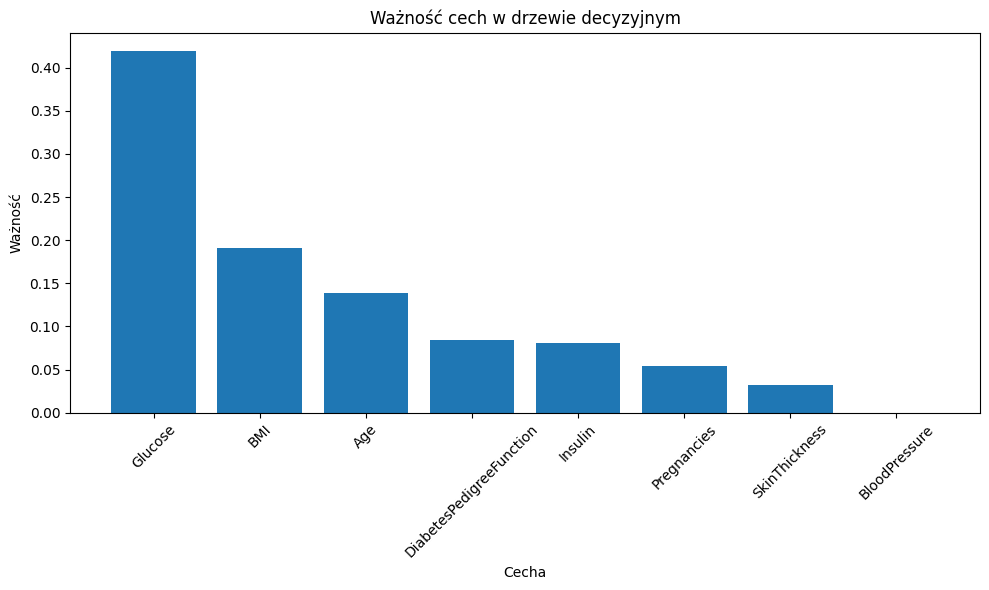

In [12]:
tree_model = best_model.named_steps["model"]

feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nWażność cech:")
print(feature_importances)


plt.figure(figsize=(10, 6))
plt.bar(
    feature_importances["Feature"],
    feature_importances["Importance"]
)
plt.xticks(rotation=45)
plt.title("Ważność cech w drzewie decyzyjnym")
plt.xlabel("Cecha")
plt.ylabel("Ważność")
plt.tight_layout()
plt.show()

# WIZUALIZACJA DRZEWA

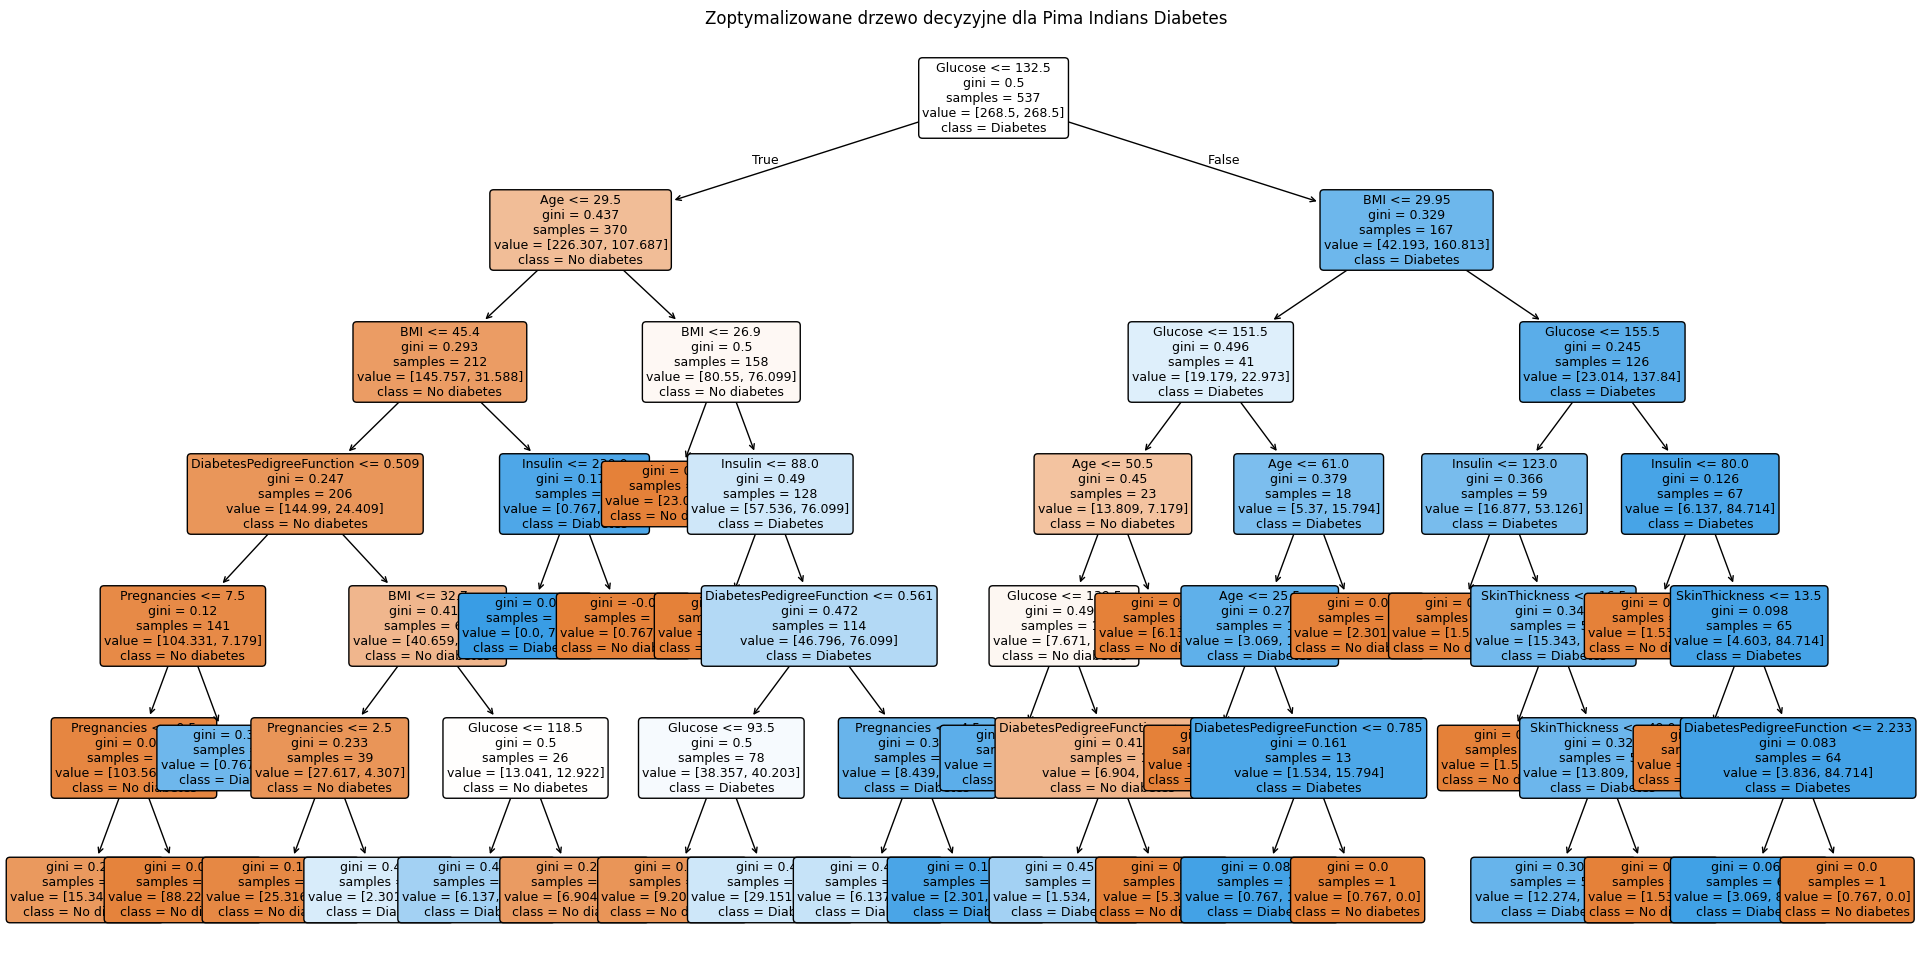

In [13]:
plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Zoptymalizowane drzewo decyzyjne dla Pima Indians Diabetes")
plt.show()

# PREDYKCJA DLA NOWEJ OSOBY

In [14]:
new_patient = pd.DataFrame(
    [[
        3,        # Pregnancies
        140,      # Glucose
        80,       # BloodPressure
        25,       # SkinThickness
        0,        # Insulin, tu 0 będzie potraktowane jako brak danych
        32.5,     # BMI
        0.45,     # DiabetesPedigreeFunction
        42        # Age
    ]],
    columns=X.columns
)

# Zamiana zer na NaN także dla nowego pacjenta

for col in zero_as_missing_columns:
    new_patient[col] = new_patient[col].replace(0, np.nan)

prediction = best_model.predict(new_patient)
prediction_proba = best_model.predict_proba(new_patient)

print("\nPredykcja dla nowej osoby:")

if prediction[0] == 1:
    print("Wynik: podwyższone ryzyko cukrzycy")
else:
    print("Wynik: brak podwyższonego ryzyka cukrzycy")

print("Prawdopodobieństwa klas:")
print("No diabetes:", prediction_proba[0][0])
print("Diabetes:", prediction_proba[0][1])


Predykcja dla nowej osoby:
Wynik: podwyższone ryzyko cukrzycy
Prawdopodobieństwa klas:
No diabetes: 0.187680341236984
Diabetes: 0.812319658763016
